## Prueba de hipotesis en dataset sintetico

Datos sinteticos generado por el siguiente link: __[link](https://www.mockaroo.com/)__

### Enunciado
`El equipo de investigación ha sido convocado para analizar los factores que
influyen en los hábitos de sueño, alimentación y actividad física en jóvenes
universitarios. La necesidad radica en identificar patrones comunes, causas
probables y generar un informe científico que oriente nuevas políticas de
bienestar estudiantil. Este proyecto requiere aplicar metodologías científicas
rigurosas y realizar un estudio estadístico que respalde las recomendaciones`

Hipotesis:
> h_1 : Las horas de sueño estan relacionadas a la cantidad de actividad fisica y el alcohol.
> h_0 : no hay diferencia de las horas de sueño entre alumnos que consumen alcohol junto con hacer actividad fisica, de los que no hacen ninguna de estas dos.

### Preparacion de los datos

Dado que el dataset fue generado, este no contiene valores nulos ni duplicados.
Sin embargo, por limitaciones del algoritmo que genero estos datos, la columna de tiempo de actividad y la de tipo de actividad continen datos incoherentes, como los es 35 minutos de "no actividad". Por esto, todos las filas en las que se presente "no activity" la columna minutos de actividad fisica correspondiente es cero.

### Criterios

se considera actividad fisica cuando los minutos de dicha actividad son mayores a 10.
se considera para el grupo de consumidores de cafeina todos aquellos que consumen mas de 250 ml  

In [ ]:
import numpy as np
import seaborn as sb
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap as lsc
from scipy import stats as scpystats

rdata = pd.read_csv("datos_salud_alumn_gen.csv")
rdatasin_na = rdata.dropna().drop_duplicates()
rdatasin_na.loc[ rdatasin_na["Tipo_actividad_fisica"] == "no activity" , "Minutos_actividad_fisica" ] = 0
rdatasin_na.info()
rdatasin_na.describe()
noconsumo_niactiv = rdatasin_na[ (rdatasin_na["Minutos_actividad_fisica"] <= 10 ) & (rdatasin_na["Cafeina_consumida"] <= 250) ]
conconsumo_act = rdatasin_na[ (rdatasin_na["Minutos_actividad_fisica"] >= 10 ) & (rdatasin_na["Cafeina_consumida"] >= 250) ]
print(f"Tamaño muestras: grupo actividad fisica {conconsumo_act.shape[0] } , restante {noconsumo_niactiv.shape[0] }")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_persona                1000 non-null   int64  
 1   Fecha                     1000 non-null   object 
 2   Horas_de_sueño            1000 non-null   float64
 3   Calorias                  1000 non-null   int64  
 4   Cantidad_comidas_dia      1000 non-null   int64  
 5   Tipo_actividad_fisica     1000 non-null   object 
 6   Minutos_actividad_fisica  1000 non-null   int64  
 7   Litros_de_agua_cosum      1000 non-null   float64
 8   Cafeina_consumida         1000 non-null   int64  
 9   Alcohol_consumido         1000 non-null   float64
 10  Nivel_de_estres           1000 non-null   object 
dtypes: float64(3), int64(5), object(3)
memory usage: 86.1+ KB
 tamaño muestras: grupo actividad fisica 611 , restante 56


<Axes: >

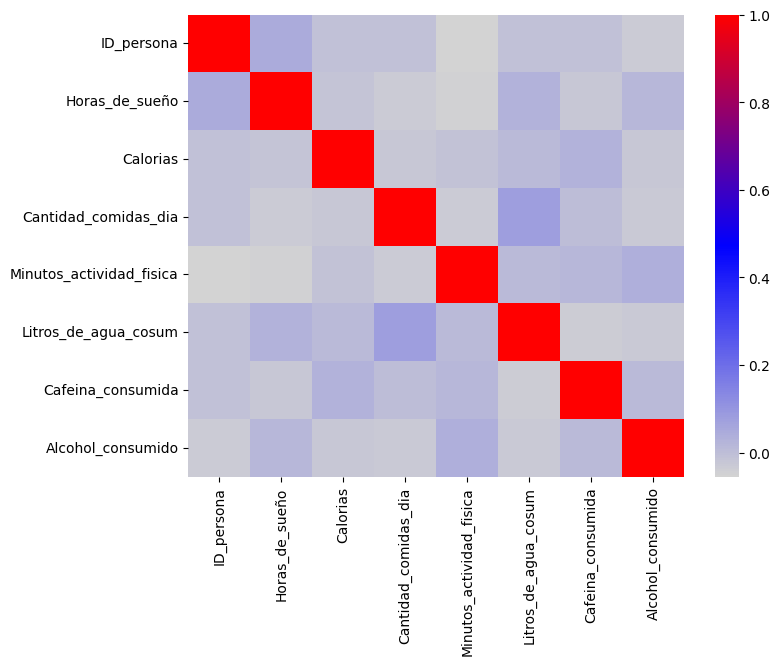

In [2]:
corr_m = rdatasin_na.corr( numeric_only=True )
colmap = lsc.from_list( "asdf" , colors=["lightgray" , "Blue" , "red"] )
fig , ax1 = plt.subplots(1 , 1 , figsize=(8 , 6))
sb.heatmap( corr_m , ax= ax1 , cmap=colmap )

<Axes: xlabel='Horas_de_sueño', ylabel='Count'>

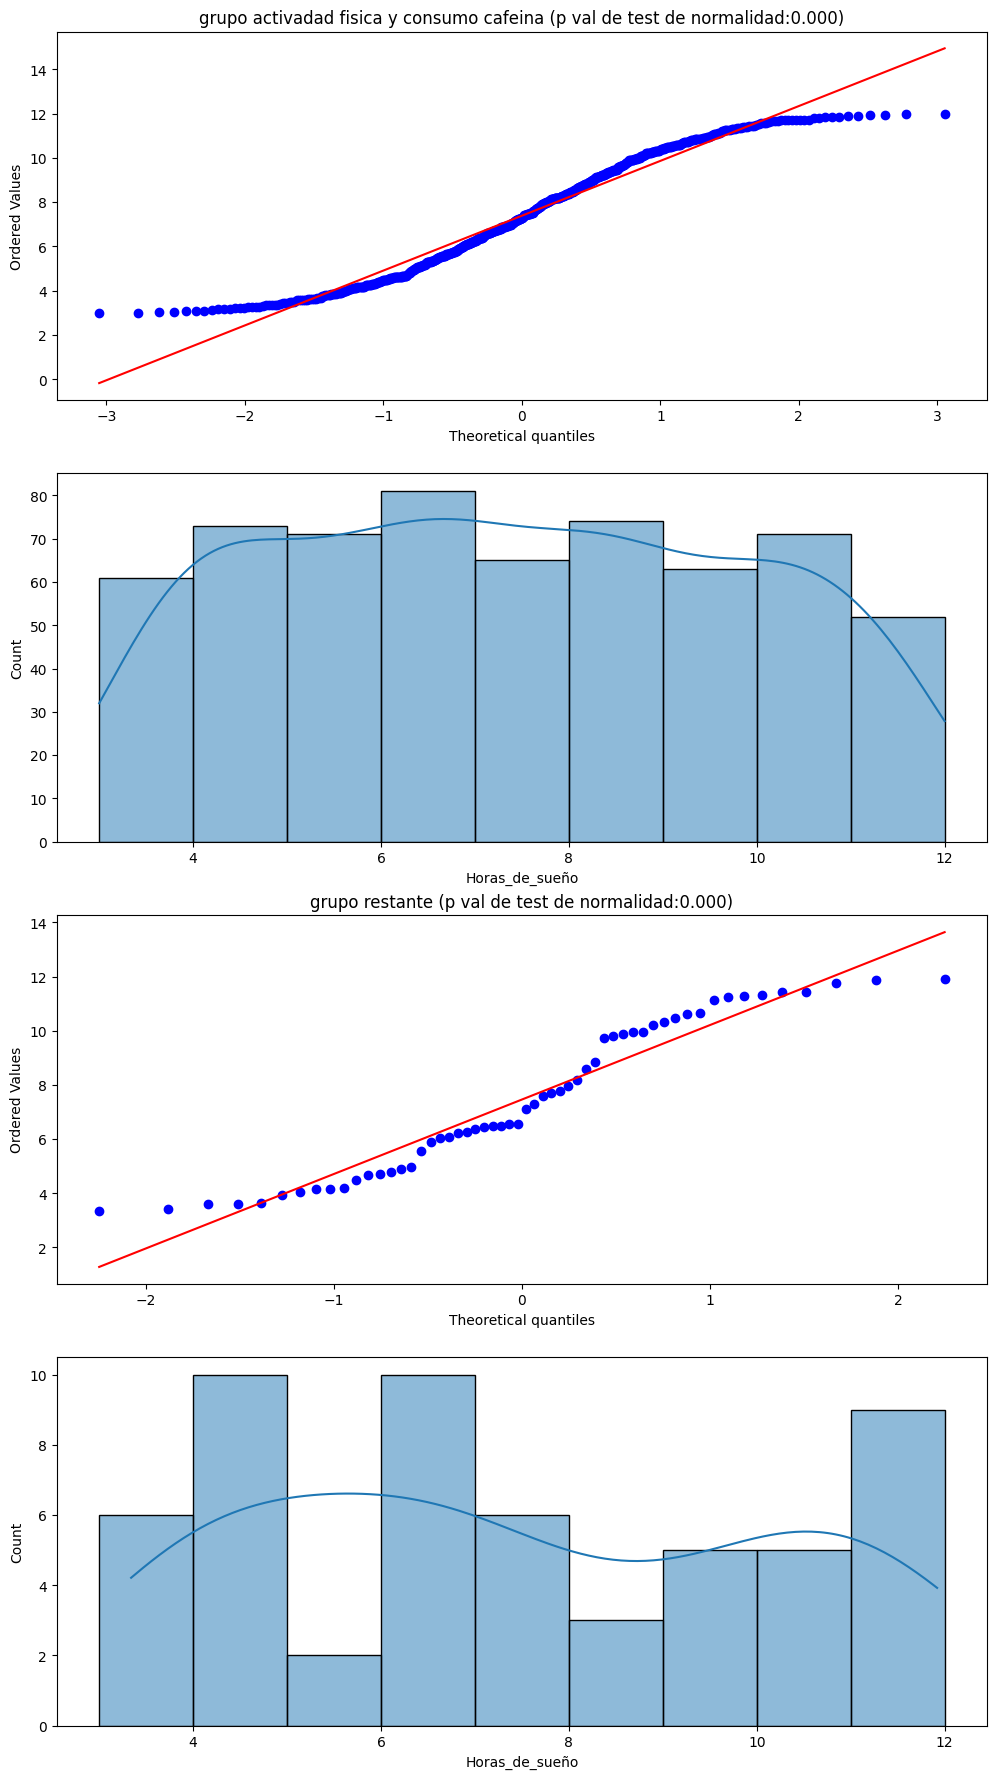

In [ ]:

fig , axes = plt.subplots(4 , 1 , figsize=(12 , 22))

p_normal1 = scpystats.normaltest( conconsumo_act["Horas_de_sueño"]).pvalue
p_normal2 = scpystats.normaltest( noconsumo_niactiv["Horas_de_sueño"]).pvalue

plt.sca( axes[0])
_ = scpystats.probplot( conconsumo_act["Horas_de_sueño"] , dist="norm", plot=plt )
plt.title(f"grupo activadad fisica y consumo cafeina (p val de test de normalidad:{p_normal1:.3f})")
sb.histplot(conconsumo_act , x = "Horas_de_sueño" , bins=9 , ax= axes[1] , kde=True, binwidth=1.0 , binrange=(3,12))
plt.sca( axes[2])
_ = scpystats.probplot( noconsumo_niactiv["Horas_de_sueño"] , dist="norm", plot=plt)
plt.title(f"grupo restante (p val de test de normalidad:{p_normal2:.3f})")
sb.histplot( noconsumo_niactiv , x = "Horas_de_sueño" , bins=9 , ax= axes[3] , kde=True, binwidth=1.0 , binrange=(3,12) )



### Analisis de las muestras

Se aprecia que ambos grupos no siguen una distribucion normal tanto por los test de normalidad (ambos practicamente 0) como por sus graficos Q-Q, sin embargo dada el tamaño de cada muestra, 650 y 56, se justifica la prueba muestral T-student.

In [29]:
hsue_conAct = conconsumo_act["Horas_de_sueño"]
hsue_sinAct = noconsumo_niactiv["Horas_de_sueño"]
cmean = hsue_conAct.mean()
smean = hsue_sinAct.mean()
alfa = 0.05

print(f"promedio h. de sueño para grupo actividad fisica y consumo de cafeina {cmean}")
print(f"promedio h. de sueño para el resto {smean}\n")
print(f"Desviacion estandar: con={hsue_conAct.std():.4f} sin={hsue_sinAct.std():.4f}")
print(f"Diferencia:{hsue_conAct.std() - hsue_sinAct.std() :.4f} ")
valort , p = scpystats.ttest_ind( hsue_conAct, hsue_sinAct , equal_var=False )
print(f"estadistico: {valort} , p value: {p} ")

promedio h. de sueño para grupo actividad fisica y consumo de cafeina 7.387692307692308
promedio h. de sueño para el resto 7.461964285714286

Desviacion estandar: con=2.5135 sin=2.7721
Diferencia:-0.2587 
estadistico: -0.1933440119191383 , p value: 0.8473060126108669 


### Conclusion

Con un valor p de 0.847 , mucho mayor a alfa, se confirma la hipotesis nula sobre el efecto del ejercicio y cafeina sobre las horas de sueño.